# 🎵 Yambda Dataset — Exploratory Data Analysis

Датасет Yambda — это крупная коллекция событий взаимодействий пользователей с музыкальным сервисом Яндекс Музыки.  
В этом ноутбуке мы исследуем структуру, распределения и паттерны поведения пользователей.

**Источник:** `yandex/yambda` на HuggingFace  
**Версия:** `flat / 50m`

## 0. Установка зависимостей

In [ ]:
# Раскомментируй если нужно установить
# !pip install datasets pandas numpy matplotlib seaborn plotly scipy

## 1. Импорты

In [10]:
import sys
sys.path.append('/Users/n.mamashakirov/PycharmProjects/hseml-group-project-nurtilekmamashakirov-2/src')

In [3]:
from typing import Literal
from datasets import Dataset, DatasetDict, load_dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 5)


## 2. Загрузка датасета

In [12]:
from data.yambda_dataset import get_yambda_pandas

df = get_yambda_pandas()
print(f'Загружено: {len(df):,} строк')

Загружено: 47,790,449 строк


## 3. Базовая информация о датасете

In [13]:
print('=' * 55)
print('ОБЩАЯ ИНФОРМАЦИЯ')
print('=' * 55)
print(f'Строк:    {len(df):>15,}')
print(f'Колонок:  {df.shape[1]:>15}')
print(f'Памяти:   {df.memory_usage(deep=True).sum() / 1024**2:>14.1f} MB')
print('=' * 55)
df.info()

ОБЩАЯ ИНФОРМАЦИЯ
Строк:         47,790,449
Колонок:                7
Памяти:           1958.3 MB
<class 'pandas.DataFrame'>
RangeIndex: 47790449 entries, 0 to 47790448
Data columns (total 7 columns):
 #   Column                Dtype  
---  ------                -----  
 0   uid                   uint32 
 1   timestamp             uint32 
 2   item_id               uint32 
 3   is_organic            uint8  
 4   played_ratio_pct      float64
 5   track_length_seconds  float64
 6   event_type            str    
dtypes: float64(2), str(1), uint32(3), uint8(1)
memory usage: 1.9 GB


In [14]:
# Первые строки
df.head(10)

,uid,timestamp,item_id,is_organic,played_ratio_pct,track_length_seconds,event_type
0,100,39420,8326270,0,100.0,170.0,listen
1,100,39420,1441281,0,100.0,105.0,listen
2,100,39625,286361,0,100.0,185.0,listen
3,100,40110,732449,0,100.0,240.0,listen
4,100,40360,3397170,0,46.0,130.0,listen
5,100,40380,7849270,0,100.0,205.0,listen
6,100,40640,1449307,0,100.0,205.0,listen
7,100,40785,6887232,0,100.0,145.0,listen
8,100,40885,2996197,0,100.0,95.0,listen
9,100,41130,6474571,0,100.0,245.0,listen


In [15]:
# Статистика числовых колонок
df.describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).round(2)

,uid,timestamp,item_id,is_organic,played_ratio_pct,track_length_seconds
count,47790449.00,47790449.00,47790449.00,47790449.00,46467212.00,46467212.00
mean,498506.90,14446548.21,4713664.46,0.52,64.76,207.41
std,287309.57,7469606.18,2701368.21,0.50,44.09,89.21
min,100.00,0.00,22.00,0.00,0.00,5.00
1%,11700.00,383670.00,105793.04,0.00,0.00,95.00
5%,52500.00,1795665.00,496258.00,0.00,0.00,120.00
25%,249400.00,8185690.00,2395697.00,0.00,7.00,165.00
50%,494500.00,15090975.00,4715228.00,1.00,100.00,200.00
75%,744700.00,21061390.00,7050041.00,1.00,100.00,230.00
95%,948200.00,25058315.00,8933722.60,1.00,100.00,310.00


## 4. Пропущенные значения

                      missing_count  missing_pct
played_ratio_pct            1323237         2.77
track_length_seconds        1323237         2.77


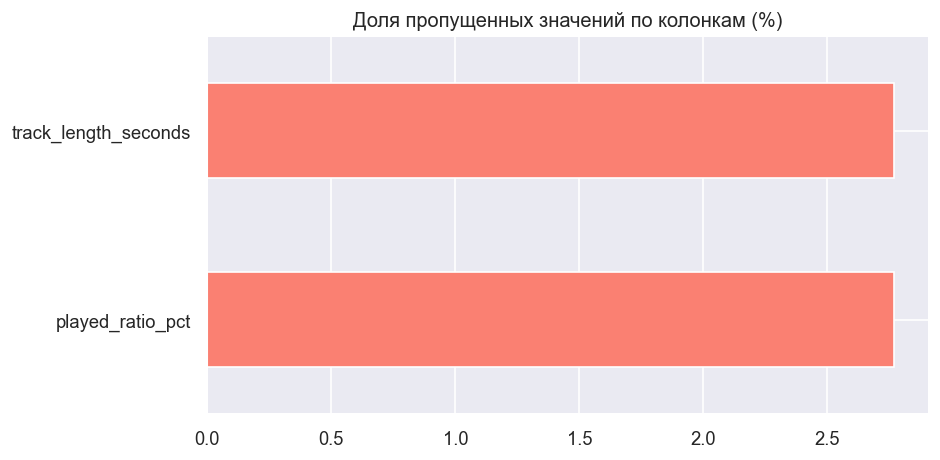

In [16]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_df = missing_df[missing_df['missing_count'] > 0]

if missing_df.empty:
    print('Пропущенных значений нет!')
else:
    print(missing_df)
    fig, ax = plt.subplots(figsize=(8, 4))
    missing_df['missing_pct'].plot(kind='barh', ax=ax, color='salmon')
    ax.set_title('Доля пропущенных значений по колонкам (%)')
    plt.tight_layout()
    plt.show()

## 5. Анализ event_type

Распределение event_type:
               count    pct
event_type                 
listen      46467212  97.23
like          881456   1.84
unlike        312972   0.65
dislike       107776   0.23
undislike      21033   0.04


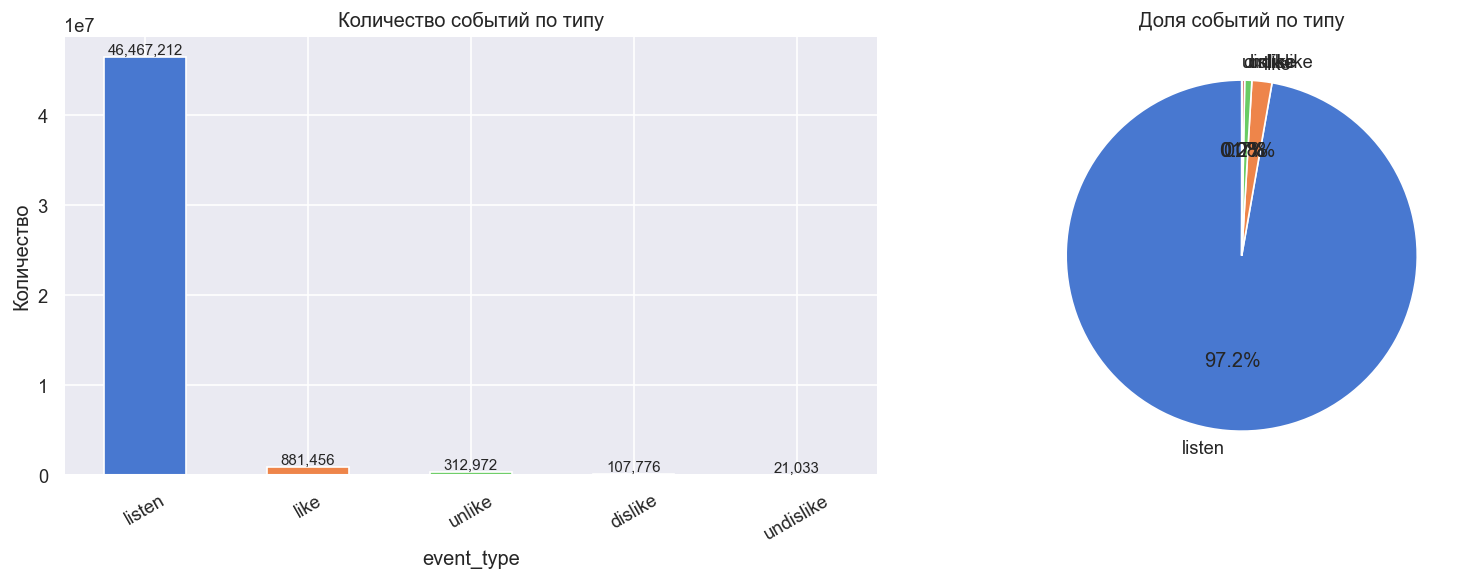

In [17]:
event_counts = df['event_type'].value_counts()
print('Распределение event_type:')
print(event_counts.to_frame('count').assign(pct=lambda x: (x['count'] / len(df) * 100).round(2)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
event_counts.plot(kind='bar', ax=axes[0], color=sns.color_palette('muted', len(event_counts)))
axes[0].set_title('Количество событий по типу')
axes[0].set_xlabel('event_type')
axes[0].set_ylabel('Количество')
axes[0].tick_params(axis='x', rotation=30)
for bar in axes[0].patches:
    axes[0].annotate(f'{int(bar.get_height()):,}',
                     (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                     ha='center', va='bottom', fontsize=9)

# Pie chart
axes[1].pie(event_counts, labels=event_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('muted', len(event_counts)), startangle=90)
axes[1].set_title('Доля событий по типу')

plt.tight_layout()
plt.show()

## 6. Анализ is_organic (органические vs рекомендованные)

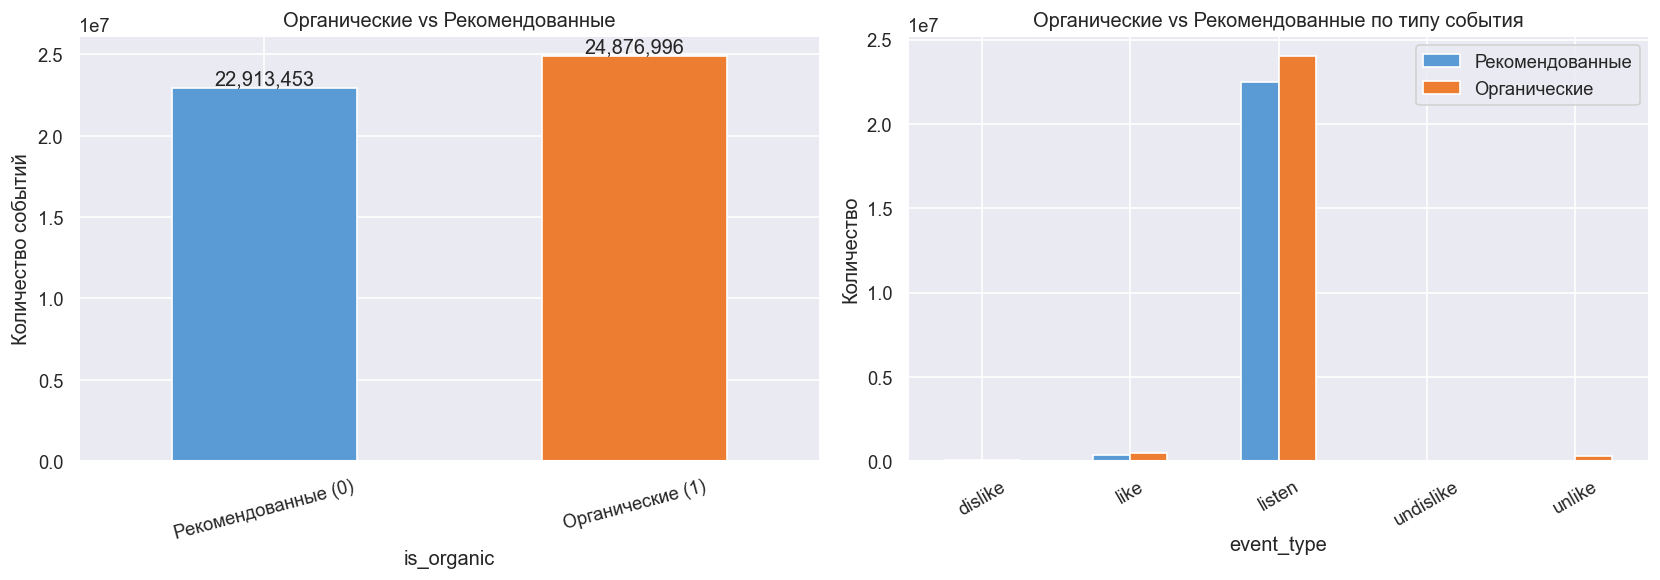


Доля органических: 52.1%
Доля рекомендованных: 47.9%


In [18]:
organic_counts = df['is_organic'].value_counts().sort_index()
labels = {0: 'Рекомендованные (0)', 1: 'Органические (1)'}
organic_counts.index = organic_counts.index.map(labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

organic_counts.plot(kind='bar', ax=axes[0], color=['#5B9BD5', '#ED7D31'])
axes[0].set_title('Органические vs Рекомендованные')
axes[0].set_ylabel('Количество событий')
axes[0].tick_params(axis='x', rotation=15)
for bar in axes[0].patches:
    axes[0].annotate(f'{int(bar.get_height()):,}',
                     (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                     ha='center', va='bottom')

# По типу события
organic_by_event = df.groupby(['event_type', 'is_organic']).size().unstack(fill_value=0)
organic_by_event.columns = ['Рекомендованные', 'Органические']
organic_by_event.plot(kind='bar', ax=axes[1], color=['#5B9BD5', '#ED7D31'])
axes[1].set_title('Органические vs Рекомендованные по типу события')
axes[1].set_ylabel('Количество')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nДоля органических: {df['is_organic'].mean():.1%}")
print(f"Доля рекомендованных: {1 - df['is_organic'].mean():.1%}")

## 7. Анализ played_ratio_pct (процент прослушивания)

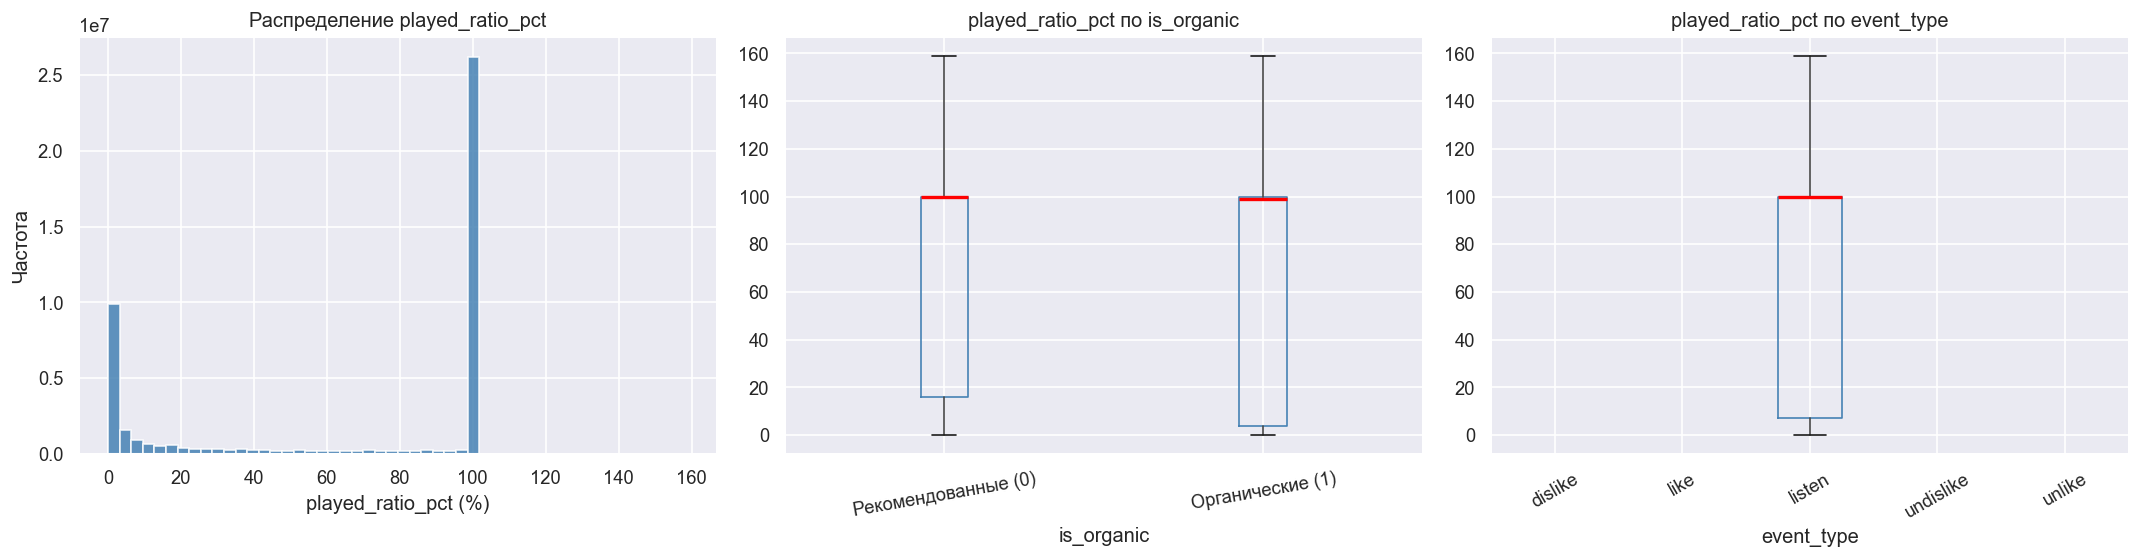


Распределение по бакетам played_ratio_pct:
                  count    pct
played_bucket                 
0-10%          12617608  26.40
10-25%          2277500   4.77
25-50%          2201713   4.61
50-75%          1558088   3.26
75-90%           910173   1.90
90-100%        26683985  55.84


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Гистограмма
axes[0].hist(df['played_ratio_pct'].dropna(), bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Распределение played_ratio_pct')
axes[0].set_xlabel('played_ratio_pct (%)')
axes[0].set_ylabel('Частота')

# Boxplot по is_organic
df.boxplot(column='played_ratio_pct', by='is_organic', ax=axes[1],
           boxprops=dict(color='steelblue'), medianprops=dict(color='red', linewidth=2))
axes[1].set_title('played_ratio_pct по is_organic')
axes[1].set_xlabel('is_organic')
plt.sca(axes[1])
plt.xticks([1, 2], ['Рекомендованные (0)', 'Органические (1)'], rotation=10)

# Boxplot по event_type
df.boxplot(column='played_ratio_pct', by='event_type', ax=axes[2],
           boxprops=dict(color='steelblue'), medianprops=dict(color='red', linewidth=2))
axes[2].set_title('played_ratio_pct по event_type')
axes[2].set_xlabel('event_type')
axes[2].tick_params(axis='x', rotation=30)

plt.suptitle('')
plt.tight_layout()
plt.show()

# Бинарное разбиение
bins = [0, 10, 25, 50, 75, 90, 100]
labels_bins = ['0-10%', '10-25%', '25-50%', '50-75%', '75-90%', '90-100%']
df['played_bucket'] = pd.cut(df['played_ratio_pct'], bins=bins, labels=labels_bins, include_lowest=True)
print('\nРаспределение по бакетам played_ratio_pct:')
bucket_stats = df['played_bucket'].value_counts().sort_index()
print(bucket_stats.to_frame('count').assign(pct=lambda x: (x['count'] / len(df) * 100).round(2)))

## 8. Анализ track_length_seconds

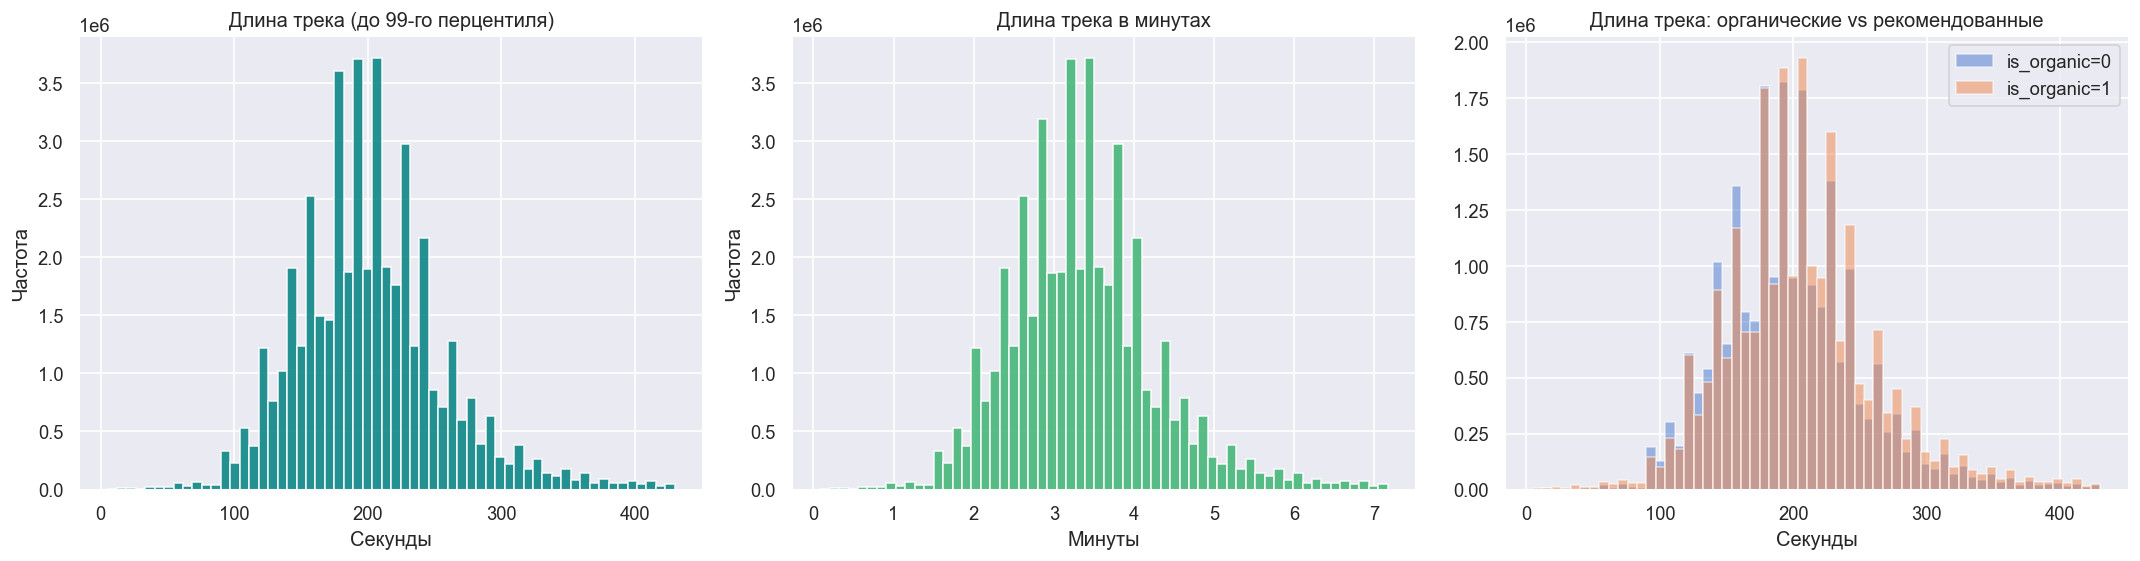

Статистика track_length_seconds:
count    46467212.0
mean          207.4
std            89.2
min             5.0
5%            120.0
25%           165.0
50%           200.0
75%           230.0
95%           310.0
max          2495.0
Name: track_length_seconds, dtype: float64


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Гистограмма (убираем выбросы > 99%)
q99 = df['track_length_seconds'].quantile(0.99)
axes[0].hist(df.loc[df['track_length_seconds'] <= q99, 'track_length_seconds'],
             bins=60, color='teal', edgecolor='white', alpha=0.85)
axes[0].set_title('Длина трека (до 99-го перцентиля)')
axes[0].set_xlabel('Секунды')
axes[0].set_ylabel('Частота')

# В минутах
df['track_length_min'] = df['track_length_seconds'] / 60
axes[1].hist(df.loc[df['track_length_min'] <= df['track_length_min'].quantile(0.99), 'track_length_min'],
             bins=60, color='mediumseagreen', edgecolor='white', alpha=0.85)
axes[1].set_title('Длина трека в минутах')
axes[1].set_xlabel('Минуты')
axes[1].set_ylabel('Частота')

# По is_organic
for label, group in df.groupby('is_organic'):
    axes[2].hist(group.loc[group['track_length_seconds'] <= q99, 'track_length_seconds'],
                 bins=60, alpha=0.5, label=f'is_organic={int(label)}')
axes[2].set_title('Длина трека: органические vs рекомендованные')
axes[2].set_xlabel('Секунды')
axes[2].legend()

plt.tight_layout()
plt.show()

print('Статистика track_length_seconds:')
print(df['track_length_seconds'].describe(percentiles=[.05, .25, .5, .75, .95]).round(1))

## 9. Анализ пользователей (uid)

=== Статистика активности пользователей ===
Уникальных пользователей: 10,000
Среднее событий на юзера: 4779.0
Медиана событий на юзера: 2654
Макс. событий у одного юзера: 27,699
Топ-10% (>= 12865 событий) юзеров генерируют 37.6% трафика


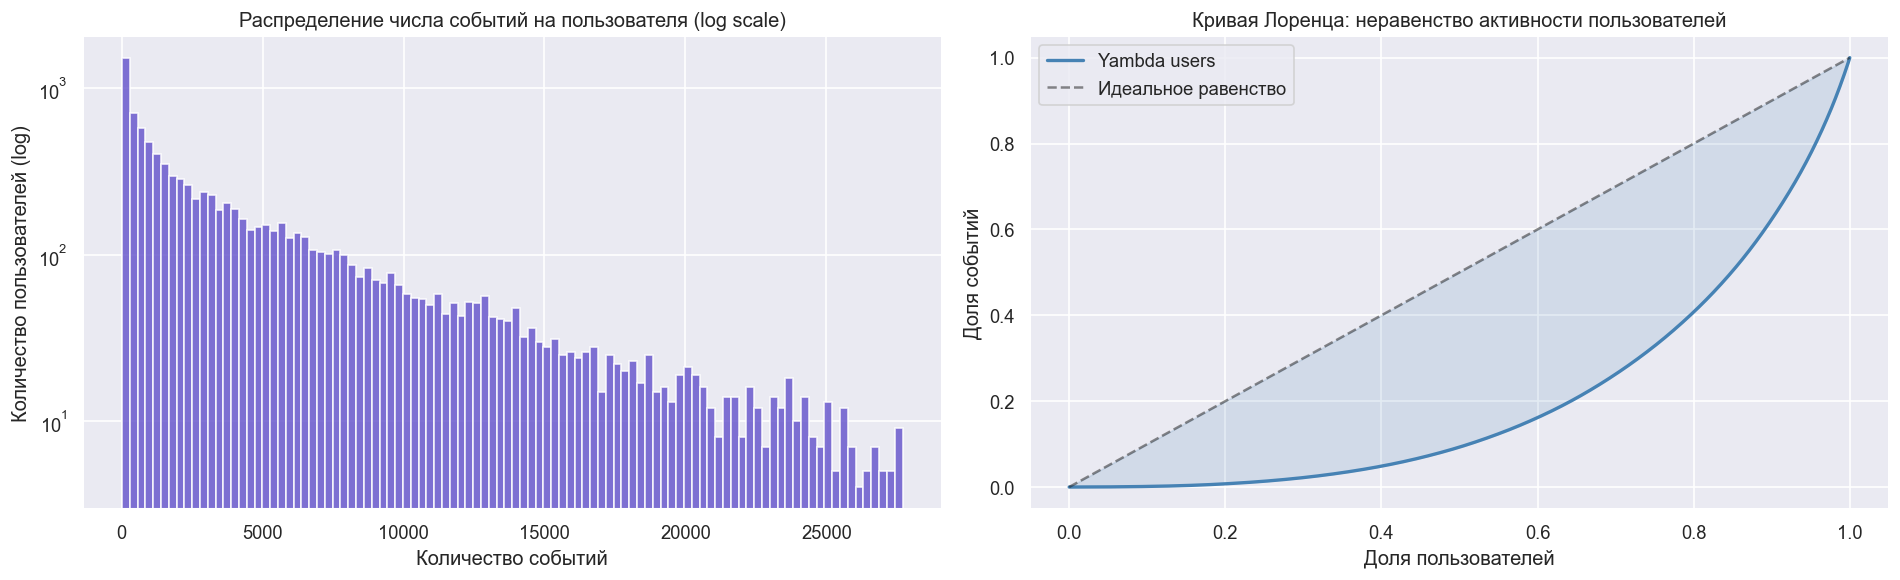

In [22]:
user_activity = df.groupby('uid').size().sort_values(ascending=False)

print('=== Статистика активности пользователей ===')
print(f'Уникальных пользователей: {df["uid"].nunique():,}')
print(f'Среднее событий на юзера: {user_activity.mean():.1f}')
print(f'Медиана событий на юзера: {user_activity.median():.0f}')
print(f'Макс. событий у одного юзера: {user_activity.max():,}')
print(f'Топ-10% (>= {user_activity.quantile(0.9):.0f} событий) юзеров генерируют '
      f'{user_activity[user_activity >= user_activity.quantile(0.9)].sum() / len(df):.1%} трафика')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Log-scale гистограмма
axes[0].hist(user_activity, bins=100, color='slateblue', edgecolor='white', alpha=0.85)
axes[0].set_yscale('log')
axes[0].set_title('Распределение числа событий на пользователя (log scale)')
axes[0].set_xlabel('Количество событий')
axes[0].set_ylabel('Количество пользователей (log)')

# Lorenz curve (неравенство)
sorted_activity = np.sort(user_activity.values)
cum_users = np.linspace(0, 1, len(sorted_activity))
cum_events = np.cumsum(sorted_activity) / sorted_activity.sum()
axes[1].plot(cum_users, cum_events, color='steelblue', lw=2, label='Yambda users')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Идеальное равенство')
axes[1].fill_between(cum_users, cum_events, cum_users, alpha=0.15, color='steelblue')
axes[1].set_title('Кривая Лоренца: неравенство активности пользователей')
axes[1].set_xlabel('Доля пользователей')
axes[1].set_ylabel('Доля событий')
axes[1].legend()

plt.tight_layout()
plt.show()

## 10. Анализ треков (item_id)

=== Статистика популярности треков ===
Уникальных треков: 934,057
Среднее прослушиваний на трек: 51.2
Медиана прослушиваний: 3
Самый популярный трек: 5862961 (42,960 событий)


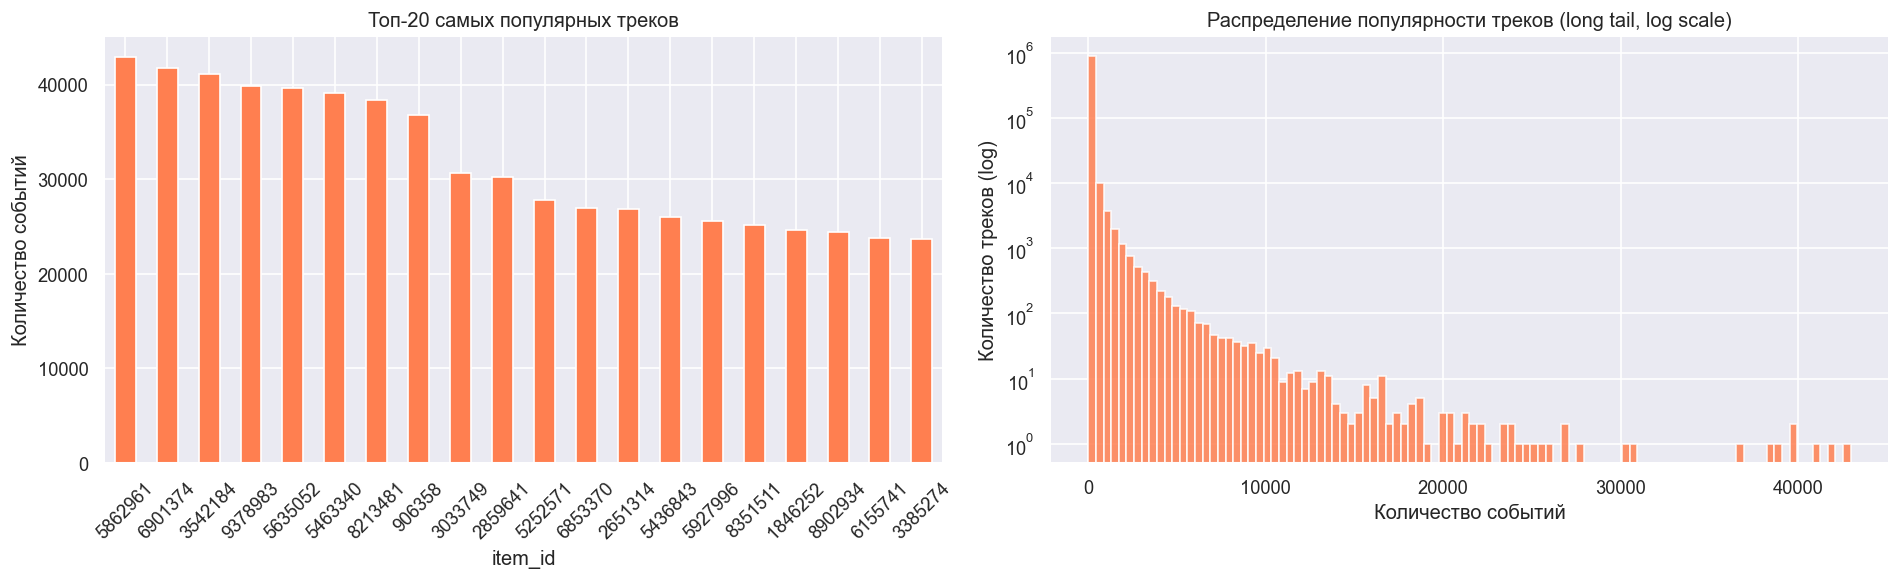

Топ 1% треков → 50.1% всех событий
Топ 5% треков → 78.9% всех событий
Топ 10% треков → 88.3% всех событий
Топ 20% треков → 94.6% всех событий


In [23]:
item_popularity = df.groupby('item_id').size().sort_values(ascending=False)

print('=== Статистика популярности треков ===')
print(f'Уникальных треков: {df["item_id"].nunique():,}')
print(f'Среднее прослушиваний на трек: {item_popularity.mean():.1f}')
print(f'Медиана прослушиваний: {item_popularity.median():.0f}')
print(f'Самый популярный трек: {item_popularity.idxmax()} ({item_popularity.max():,} событий)')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Топ-20 треков
top20 = item_popularity.head(20)
top20.plot(kind='bar', ax=axes[0], color='coral')
axes[0].set_title('Топ-20 самых популярных треков')
axes[0].set_xlabel('item_id')
axes[0].set_ylabel('Количество событий')
axes[0].tick_params(axis='x', rotation=45)

# Хвост распределения
axes[1].hist(item_popularity, bins=100, color='coral', edgecolor='white', alpha=0.85)
axes[1].set_yscale('log')
axes[1].set_title('Распределение популярности треков (long tail, log scale)')
axes[1].set_xlabel('Количество событий')
axes[1].set_ylabel('Количество треков (log)')

plt.tight_layout()
plt.show()

# Концентрация
for pct in [1, 5, 10, 20]:
    top_n = item_popularity.head(int(len(item_popularity) * pct / 100))
    print(f'Топ {pct}% треков → {top_n.sum() / len(df):.1%} всех событий')

## 11. Анализ временных паттернов (timestamp)

Диапазон timestamp:
  Min: 0
  Max: 26,000,000
  Диапазон: 26,000,000
  Уникальных значений: 5,052,573


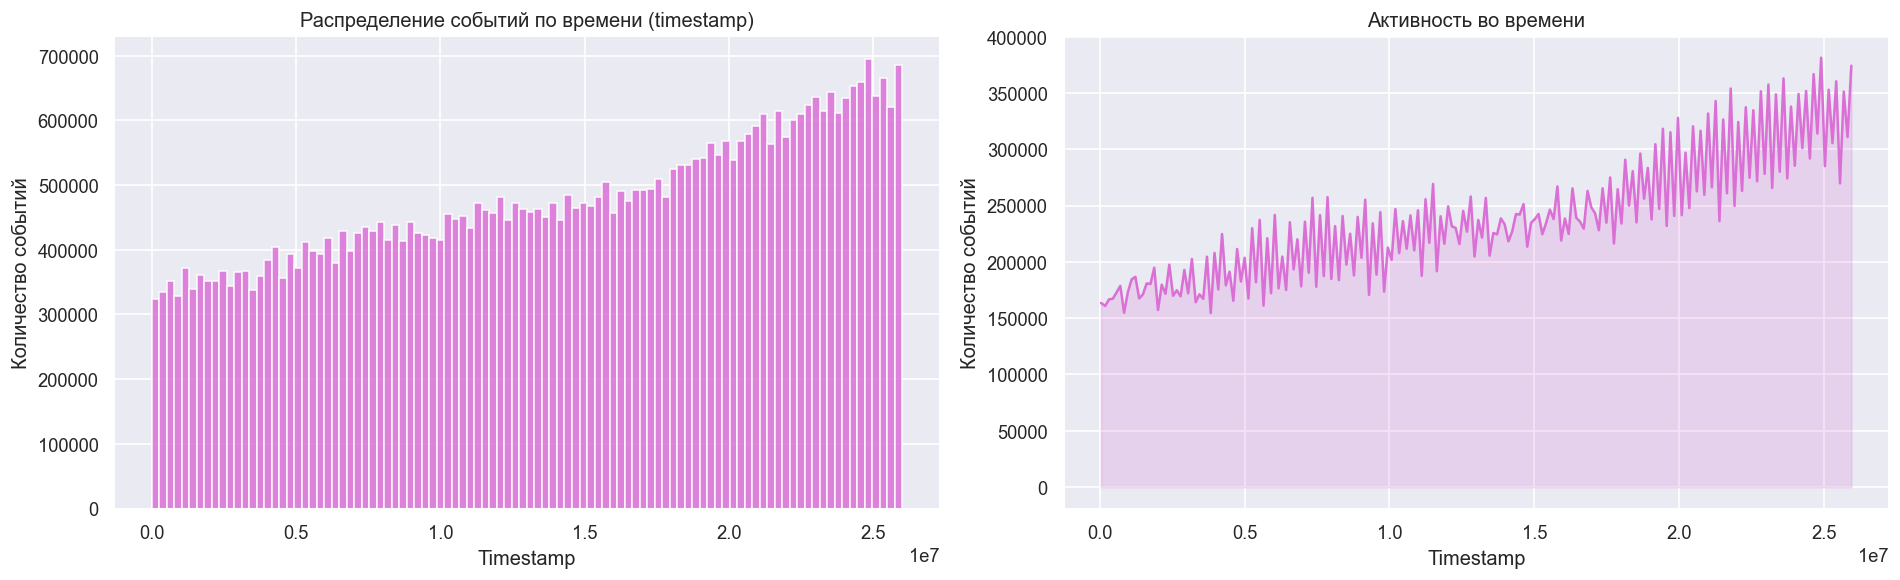

In [24]:
print('Диапазон timestamp:')
print(f'  Min: {df["timestamp"].min():,}')
print(f'  Max: {df["timestamp"].max():,}')
print(f'  Диапазон: {df["timestamp"].max() - df["timestamp"].min():,}')
print(f'  Уникальных значений: {df["timestamp"].nunique():,}')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Гистограмма timestamp
axes[0].hist(df['timestamp'], bins=100, color='orchid', edgecolor='white', alpha=0.85)
axes[0].set_title('Распределение событий по времени (timestamp)')
axes[0].set_xlabel('Timestamp')
axes[0].set_ylabel('Количество событий')

# Количество событий по timestamp (агрегированные бакеты)
ts_series = df.groupby(pd.cut(df['timestamp'], bins=200)).size()
ts_centers = [interval.mid for interval in ts_series.index]
axes[1].plot(ts_centers, ts_series.values, color='orchid', lw=1.5)
axes[1].set_title('Активность во времени')
axes[1].set_xlabel('Timestamp')
axes[1].set_ylabel('Количество событий')
axes[1].fill_between(ts_centers, ts_series.values, alpha=0.2, color='orchid')

plt.tight_layout()
plt.show()

## 12. Матрица корреляций

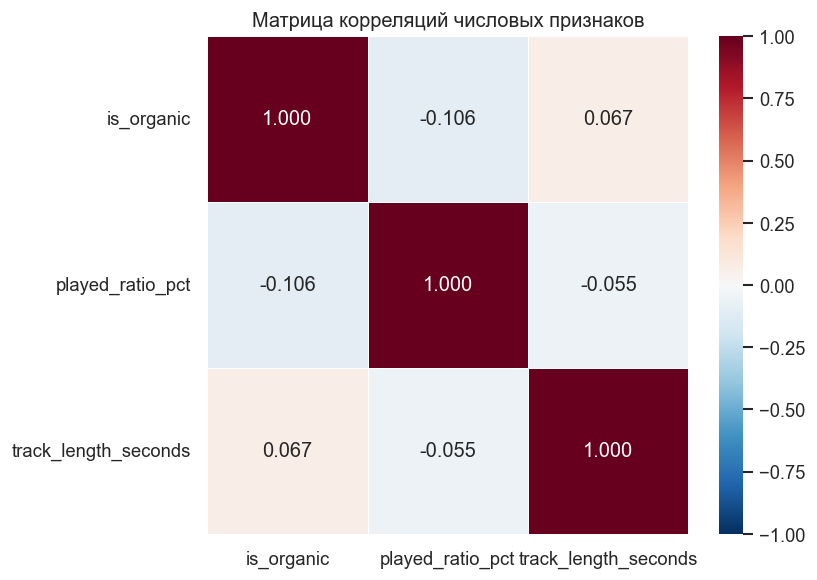

In [25]:
num_cols = ['is_organic', 'played_ratio_pct', 'track_length_seconds']
corr_matrix = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.3f', cmap='RdBu_r', center=0,
    linewidths=0.5, ax=ax, vmin=-1, vmax=1
)
ax.set_title('Матрица корреляций числовых признаков')
plt.tight_layout()
plt.show()

## 13. Сессионный анализ: поведение одного пользователя

Топ пользователь uid=997500: 27,699 событий
Временной диапазон: 13575 → 25992070
Уникальных треков: 4,631
Avg played_ratio: 96.8%


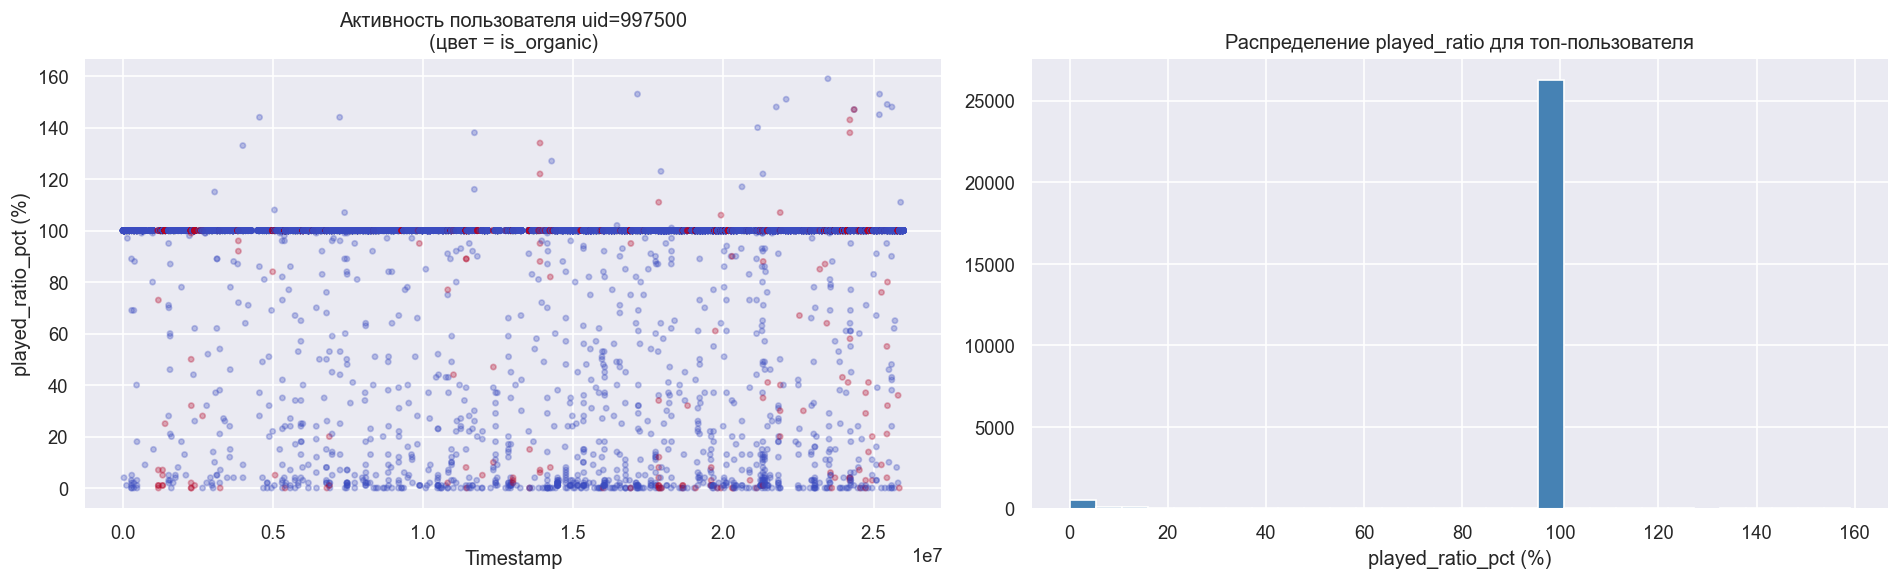

In [26]:
# Берём пользователя с наибольшим числом событий
top_user = user_activity.idxmax()
user_df = df[df['uid'] == top_user].sort_values('timestamp').reset_index(drop=True)

print(f'Топ пользователь uid={top_user}: {len(user_df):,} событий')
print(f'Временной диапазон: {user_df["timestamp"].min()} → {user_df["timestamp"].max()}')
print(f'Уникальных треков: {user_df["item_id"].nunique():,}')
print(f'Avg played_ratio: {user_df["played_ratio_pct"].mean():.1f}%')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].scatter(user_df['timestamp'], user_df['played_ratio_pct'],
                alpha=0.3, s=10, c=user_df['is_organic'], cmap='coolwarm')
axes[0].set_title(f'Активность пользователя uid={top_user}\n(цвет = is_organic)')
axes[0].set_xlabel('Timestamp')
axes[0].set_ylabel('played_ratio_pct (%)')

axes[1].hist(user_df['played_ratio_pct'], bins=30, color='steelblue', edgecolor='white')
axes[1].set_title('Распределение played_ratio для топ-пользователя')
axes[1].set_xlabel('played_ratio_pct (%)')

plt.tight_layout()
plt.show()

## 14. Полное vs неполное прослушивание

=== Паттерны прослушивания ===
Полностью прослушано (>=90%):  56.4%
Скипнуто (<10%):               25.9%
Частично прослушано (10-90%):  17.7%

Полностью прослушано по is_organic:
is_organic
0    62.5%
1    50.9%
Name: fully_listened, dtype: str


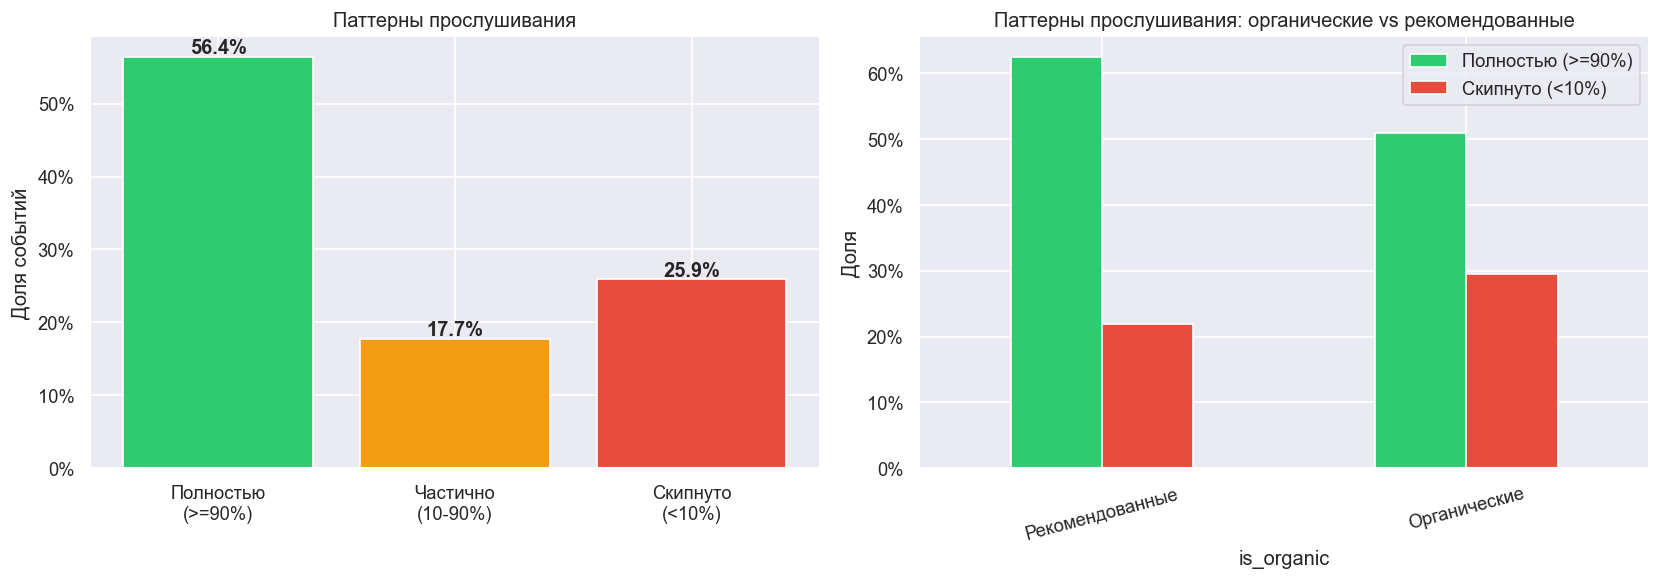

In [27]:
df['fully_listened'] = df['played_ratio_pct'] >= 90
df['skipped'] = df['played_ratio_pct'] < 10

print('=== Паттерны прослушивания ===')
print(f'Полностью прослушано (>=90%):  {df["fully_listened"].mean():.1%}')
print(f'Скипнуто (<10%):               {df["skipped"].mean():.1%}')
print(f'Частично прослушано (10-90%):  {(~df["fully_listened"] & ~df["skipped"]).mean():.1%}')

# По is_organic
print('\nПолностью прослушано по is_organic:')
print(df.groupby('is_organic')['fully_listened'].mean().map('{:.1%}'.format))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

categories = ['Полностью\n(>=90%)', 'Частично\n(10-90%)', 'Скипнуто\n(<10%)']
values = [
    df['fully_listened'].mean(),
    (~df['fully_listened'] & ~df['skipped']).mean(),
    df['skipped'].mean()
]
colors = ['#2ECC71', '#F39C12', '#E74C3C']
axes[0].bar(categories, values, color=colors, edgecolor='white')
axes[0].set_title('Паттерны прослушивания')
axes[0].set_ylabel('Доля событий')
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
for i, v in enumerate(values):
    axes[0].text(i, v + 0.005, f'{v:.1%}', ha='center', fontweight='bold')

# Сравнение organic vs recommended
listen_by_organic = df.groupby('is_organic').agg(
    fully_listened=('fully_listened', 'mean'),
    skipped=('skipped', 'mean')
).rename(index={0: 'Рекомендованные', 1: 'Органические'})

listen_by_organic[['fully_listened', 'skipped']].plot(kind='bar', ax=axes[1],
                                                        color=['#2ECC71', '#E74C3C'])
axes[1].set_title('Паттерны прослушивания: органические vs рекомендованные')
axes[1].set_ylabel('Доля')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[1].legend(['Полностью (>=90%)', 'Скипнуто (<10%)'])
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

## 15. Итоговая сводка

In [28]:
print('=' * 60)
print('ИТОГОВАЯ СВОДКА EDA — Yambda Dataset (flat/50m)')
print('=' * 60)
print(f'Размер датасета:       {len(df):>15,} строк')
print(f'Уникальных юзеров:     {df["uid"].nunique():>15,}')
print(f'Уникальных треков:     {df["item_id"].nunique():>15,}')
print(f'Типов событий:         {df["event_type"].nunique():>15}')
print(f'Органических событий:  {df["is_organic"].mean():>14.1%}')
print(f'Ср. played_ratio:      {df["played_ratio_pct"].mean():>14.1f}%')
print(f'Ср. длина трека:       {df["track_length_seconds"].mean():>13.1f} сек')
print(f'Полностью прослушано:  {df["fully_listened"].mean():>14.1%}')
print(f' Скипнуто:              {df["skipped"].mean():>14.1%}')
print('=' * 60)

ИТОГОВАЯ СВОДКА EDA — Yambda Dataset (flat/50m)
Размер датасета:            47,790,449 строк
Уникальных юзеров:              10,000
Уникальных треков:             934,057
Типов событий:                       5
Органических событий:           52.1%
Ср. played_ratio:                64.8%
Ср. длина трека:               207.4 сек
Полностью прослушано:           56.4%
 Скипнуто:                       25.9%
